In [5]:
# ==========================================================
# IMPORTS
# ==========================================================

import os
import importlib
import time
import pickle
import numpy as np
from tqdm import tqdm
from map_elites.map_elites import MAPElites
from simulation.simulation_final import HexapodTorqueSimulation, evaluate_batch_parallel_torque
from controllers.hexapod_controller_final import RecurrentTorqueHexapodController
from config import URDF_PATH
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import config as experiment_config

In [6]:
# ==========================================================
# PROJECT PATHS (synchronized with config.py)
# ==========================================================

# Prefer canonical paths defined in config.py (experiment_config) if available
PROJECT_ROOT = getattr(experiment_config, 'PROJECT_ROOT', os.getcwd())
RESULTS_DIR = getattr(experiment_config, 'RESULTS_DIR', os.path.join(PROJECT_ROOT, "results"))
os.makedirs(RESULTS_DIR, exist_ok=True)
CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
RANDOM_TRAJECTORIES_DIR = os.path.join(RESULTS_DIR, "random_trajectories")
os.makedirs(RANDOM_TRAJECTORIES_DIR, exist_ok=True)
DETAILED_LOGS_DIR = os.path.join(RESULTS_DIR, "detailed_logs")
os.makedirs(DETAILED_LOGS_DIR, exist_ok=True)

# ==========================================================
# CONTROLLER
# ==========================================================

# Controller genome size - prefer value from config module
CONTROLLER_GENOME_SIZE = getattr(experiment_config, 'CONTROLLER_GENOME_SIZE', RecurrentTorqueHexapodController.get_genome_size())

print("=" * 60)
print("PROJECT CONFIGURATION")
print("=" * 60)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"URDF_PATH: {getattr(experiment_config, 'URDF_PATH', URDF_PATH)}")
print(f"URDF exists: {os.path.exists(getattr(experiment_config, 'URDF_PATH', URDF_PATH))}")

print(f"Genome size: {CONTROLLER_GENOME_SIZE}")

# ==========================================================
# BEHAVIOR DESCRIPTOR (from config.py) + local fitness configuration
# ==========================================================

BD_MODE = 'transformer_latent'
print(f"Behavior Descriptor Mode: {BD_MODE}")

# Keep config.py as the source of truth, but sync its module globals to the notebook choice.
experiment_config.BD_MODE = BD_MODE
experiment_config.TRANSFORMER_BD_CONFIG = (
    experiment_config.get_transformer_bd_config(BD_MODE)
    if BD_MODE.startswith('transformer')
    else None
)

# Fitness configuration is intentionally local to the notebook.
FITNESS_MODE = 'combined'
DISTANCE_WEIGHT = 3.0
AVG_SPEED_WEIGHT = 0.3
STABILITY_PENALTY_WEIGHT = 0.2
ENERGY_WEIGHT = 2e-6

def get_fitness_name(mode=None):
    if mode is None:
        mode = FITNESS_MODE

    if mode == 'combined':
        return 'Locomotion Fitness'
    elif mode == 'distance':
        return 'Distance traveled'
    elif mode == 'forward_velocity':
        return 'Forward velocity'
    elif mode == 'avg_speed':
        return 'Average speed'
    elif mode == 'stability':
        return 'Stability score'
    else:
        raise ValueError(f"Unknown FITNESS_MODE '{mode}'")

# Keep using the functions from config.py.
get_behavior_descriptor_dims = experiment_config.get_behavior_descriptor_dims
get_behavior_descriptor_names = experiment_config.get_behavior_descriptor_names
TRANSFORMER_BD_CONFIG = experiment_config.TRANSFORMER_BD_CONFIG

# ==========================================================
# MAP-ELITES CONFIGURATION (local experiment override)
# ==========================================================

MAP_ELITES_CONFIG = {
    'behavior_descriptors_dims': get_behavior_descriptor_dims(),
    'genome_size': CONTROLLER_GENOME_SIZE,
    'genome_bounds': (-0.75, 0.75),
    'num_initial_random': 10000,
    'num_iterations': 5000,
    'batch_size': 64,
    'mutation_rate': 0.2,
    'mutation_strength': 0.15,
    'bd_handling': 'clip' if BD_MODE.startswith('transformer') else 'reject',
    'num_repeated_evaluations': 3,
    'seed': 42,
}
print(behaviour_descriptors_dims := MAP_ELITES_CONFIG['behavior_descriptors_dims'])

# ==========================================================
# LOGGING CONFIGURATION (local experiment override)
# ==========================================================

LOGGING_CONFIG = {
    'save_interval': 500,
    'trajectory_save_interval': 500,
    'save_random_trajectories': False,
    'trajectory_save_probability': 0.1,
    'print_interval': 1000,
    'save_grid': True,
    'save_plots': True,
    'save_detailed_logs': False,
    'num_best_to_log': 20,
    'num_random_to_log': 20,
}

experiment_config.LOGGING_CONFIG = LOGGING_CONFIG

# ==========================================================
# SIMULATION CONFIGURATION (local experiment override)
# ==========================================================

SIMULATION_CONFIG = {
    'duration': 6.0,
    'time_step': 1.0 / 240,
    'gui': False,
    'max_force': 5.0,
    'sample_interval': 1.0,
    'acceleration_threshold': 20.0,
    'warmup_time': 1.0,
    'controller_interval': 4,
}

PROJECT CONFIGURATION
PROJECT_ROOT: /home/joze/Mestrado/Dissertacao/Pybullet
URDF_PATH: /home/joze/Mestrado/Dissertacao/Pybullet/robot_models/hexapod.urdf
URDF exists: True
Genome size: 3282
Behavior Descriptor Mode: transformer_latent
[(-5.0, 5.0, 50), (-5.0, 5.0, 50)]


In [7]:
# ==========================================================
# DETAILED LOG EXPORT HELPERS
# ==========================================================

def save_detailed_logs_snapshot(map_elites, sim, iteration, num_best=20):
    cells = list(map_elites.grid.values())
    if not cells:
        print(f"No archive cells available to log at iteration {iteration}.")
        return None

    cells_sorted = sorted(cells, key=lambda x: x['fitness'], reverse=True)
    best_cells = cells_sorted[:num_best]

    detailed_logs_data = []
    for rank, cell in enumerate(best_cells, start=1):
        result = sim.evaluate_controller(
            cell['genome'],
            duration=SIMULATION_CONFIG['duration'],
            warmup_time=SIMULATION_CONFIG.get('warmup_time', 1.0),
            render=False,
            sample_interval=SIMULATION_CONFIG['sample_interval'],
            controller_interval=SIMULATION_CONFIG.get('controller_interval', 4),
            log_all_steps=True,
        )

        detailed_logs_data.append({
            'rank': rank,
            'fitness': float(cell['fitness']),
            # archive BD (from the cell) and run-computed BD (from evaluate_controller)
            'archive_behavior_descriptors': cell.get('bd'),
            'behavior_descriptors': result.get('behavior_descriptors', cell.get('bd')),
            'genome': cell['genome'],
            'detailed_log': result.get('detailed_log', []),
            'distance': float(result.get('distance', 0.0)),
            'energy': float(result.get('energy', 0.0)),
        })

    os.makedirs(DETAILED_LOGS_DIR, exist_ok=True)
    log_path = os.path.join(DETAILED_LOGS_DIR, f"detailed_logs_iter_{iteration}.pkl")
    with open(log_path, 'wb') as f:
        pickle.dump(detailed_logs_data, f)

    print(f"Saved detailed logs: {log_path} ({len(detailed_logs_data)} controllers)")
    return log_path

Transformer 8D

In [ ]:
# ==========================================================
# CREATE MAP-ELITES
# ==========================================================

map_elites = MAPElites(
    behavior_descriptors_dims=MAP_ELITES_CONFIG['behavior_descriptors_dims'],
    genome_size=MAP_ELITES_CONFIG['genome_size'],
    genome_bounds=MAP_ELITES_CONFIG['genome_bounds'],
    bd_handling=MAP_ELITES_CONFIG['bd_handling'],
    seed=MAP_ELITES_CONFIG['seed'],
)

map_elites.bd_mode = BD_MODE
map_elites.fitness_mode = FITNESS_MODE
map_elites.bd_labels = get_behavior_descriptor_names()
map_elites.fitness_label = get_fitness_name()

# ==========================================================
# INITIAL RANDOM POPULATION
# ==========================================================

initial_population = []

for _ in tqdm(
    range(MAP_ELITES_CONFIG['num_initial_random']),
    desc="Generating initial population"
):
    initial_population.append(map_elites.random_genome())

# ==========================================================
# EVALUATE INITIAL POPULATION
# ==========================================================

fitnesses, bds, final_positions = evaluate_batch_parallel_torque(initial_population)

# ==========================================================
# ADD TO ARCHIVE
# ==========================================================

for genome, fitness, bd, final_position in tqdm(
    zip(initial_population, fitnesses, bds, final_positions),
    desc="Adding initial population to archive",
    total=len(initial_population)
):
    map_elites.add_to_grid(genome, fitness, bd, final_position=final_position)

# ==========================================================
# INITIAL STATS
# ==========================================================

stats = map_elites.get_statistics()

print("\nInitial archive statistics:\n")

for k, v in stats.items():
    print(f"{k}: {v}")

# ==========================================================
# TIMER
# ==========================================================

start_time = time.time()

Adding initial population to archive: 100%|██████████| 10000/10000 [00:00<00:00, 39318.16it/s]


Initial archive statistics:

coverage: 0.00010180898491083676
num_filled: 171
max_fitness: 1.1925647614992785
mean_fitness: 0.3417387487694688
qd_score: 58.43732603957916


In [ ]:
# ==========================================================
# CELL 2 — MAIN EVOLUTION LOOP
# ==========================================================

sim_for_logging = HexapodTorqueSimulation(
    urdf_path=URDF_PATH,
    gui=False,
    time_step=SIMULATION_CONFIG['time_step'],
)

for iteration in tqdm(
    range(MAP_ELITES_CONFIG['num_iterations']),
    desc="Iterations"
 ):

    # ------------------------------------------------------
    # SAMPLE PARENTS
    # ------------------------------------------------------

    parents = []

    for _ in tqdm(
        range(MAP_ELITES_CONFIG['batch_size']),
        desc="Selecting parents",
        leave=False
    ):
        parents.append(map_elites.random_selection())

    # ------------------------------------------------------
    # MUTATE
    # ------------------------------------------------------

    offspring = []

    for parent in tqdm(
        parents,
        desc="Mutating parents",
        leave=False
    ):

        child = map_elites.mutate(
            genome=parent,
            mutation_rate=MAP_ELITES_CONFIG['mutation_rate'],
            mutation_strength=MAP_ELITES_CONFIG['mutation_strength']
        )

        offspring.append(child)

    # ------------------------------------------------------
    # EVALUATE OFFSPRING
    # ------------------------------------------------------

    fitnesses, bds, final_positions = evaluate_batch_parallel_torque(offspring)

    # ------------------------------------------------------
    # ADD TO ARCHIVE
    # ------------------------------------------------------

    for genome, fitness, bd, final_position in tqdm(
        zip(offspring, fitnesses, bds, final_positions),
        desc="Adding offspring to archive",
        total=len(offspring),
        leave=False
    ):
        map_elites.add_to_grid(genome, fitness, bd, final_position=final_position)

    # ------------------------------------------------------
    # UPDATE HISTORY
    # ------------------------------------------------------

    map_elites.update_history()

    # ------------------------------------------------------
    # CHECKPOINT
    # ------------------------------------------------------

    if iteration % LOGGING_CONFIG['save_interval'] == 0:

        checkpoint_path = os.path.join(
            CHECKPOINT_DIR,
            f"map_elites_iter_{iteration}.pkl"
        )

        map_elites.save(checkpoint_path)

        if LOGGING_CONFIG.get('save_detailed_logs', False):
            save_detailed_logs_snapshot(
                map_elites,
                sim_for_logging,
                iteration=iteration,
                num_best=LOGGING_CONFIG.get('num_best_to_log', 20),
            )

        stats = map_elites.get_statistics()

        elapsed = time.time() - start_time

        print("\n================================================")
        print(f"Iteration: {iteration}")
        print("================================================")
        print(f"Coverage:      {stats['coverage']:.4f}")
        print(f"Filled cells:  {stats['num_filled']}")
        print(f"Max fitness:   {stats['max_fitness']:.4f}")
        print(f"QD score:      {stats['qd_score']:.4f}")
        print(f"Elapsed:       {elapsed/60:.2f} min")
        print("================================================\n")

# ==========================================================
# SAVE FINAL ARCHIVE
# ==========================================================

final_archive_path = os.path.join(RESULTS_DIR, "map_elites_final.pkl")
map_elites.save(final_archive_path)
print(f"Final archive saved to: {final_archive_path}")

if LOGGING_CONFIG.get('save_detailed_logs', False):
    save_detailed_logs_snapshot(
        map_elites,
        sim_for_logging,
        iteration='final',
        num_best=LOGGING_CONFIG.get('num_best_to_log', 20),
    )

final_stats = map_elites.get_statistics()
print("\nFinal archive statistics:\n")
for k, v in final_stats.items():
    print(f"{k}: {v}")

sim_for_logging.disconnect()

Iterations:   0%|          | 1/5000 [00:21<30:05:47, 21.67s/it]


Iteration: 0
Coverage:      0.0001
Filled cells:  171
Max fitness:   1.1926
QD score:      59.2050
Elapsed:       21.35 min



Iterations:  10%|█         | 501/5000 [2:59:46<26:05:14, 20.87s/it]


Iteration: 500
Coverage:      0.0002
Filled cells:  299
Max fitness:   1.6216
QD score:      172.7405
Elapsed:       200.77 min



Iterations:  20%|██        | 1001/5000 [5:58:13<23:19:19, 21.00s/it]

...


Iteration: 4000
Coverage:      0.0003
Filled cells:  466
Max fitness:   2.6125
QD score:      373.1255
Elapsed:       1415.39 min



Iterations:  90%|█████████ | 4501/5000 [26:07:13<2:51:35, 20.63s/it]


Iteration: 4500
Coverage:      0.0003
Filled cells:  475
Max fitness:   2.6125
QD score:      394.4255
Elapsed:       1588.22 min



Iterations: 100%|██████████| 5000/5000 [28:58:50<00:00, 20.87s/it]  

Final archive saved to: /home/joze/Mestrado/Dissertacao/Pybullet/results/map_elites_final.pkl

Final archive statistics:

coverage: 0.00028697035512879134
num_filled: 482
max_fitness: 3.0576662728761064
mean_fitness: 0.8581035949131355
qd_score: 413.6059327481313


Transformer

In [4]:
# ==========================================================
# CREATE MAP-ELITES
# ==========================================================

map_elites = MAPElites(
    behavior_descriptors_dims=MAP_ELITES_CONFIG['behavior_descriptors_dims'],
    genome_size=MAP_ELITES_CONFIG['genome_size'],
    genome_bounds=MAP_ELITES_CONFIG['genome_bounds'],
    bd_handling=MAP_ELITES_CONFIG['bd_handling'],
    seed=MAP_ELITES_CONFIG['seed'],
)

map_elites.bd_mode = BD_MODE
map_elites.fitness_mode = FITNESS_MODE
map_elites.bd_labels = get_behavior_descriptor_names()
map_elites.fitness_label = get_fitness_name()

# ==========================================================
# INITIAL RANDOM POPULATION
# ==========================================================

initial_population = []

for _ in tqdm(
    range(MAP_ELITES_CONFIG['num_initial_random']),
    desc="Generating initial population"
):
    initial_population.append(map_elites.random_genome())

# ==========================================================
# EVALUATE INITIAL POPULATION
# ==========================================================

fitnesses, bds, final_positions = evaluate_batch_parallel_torque(initial_population)

# ==========================================================
# ADD TO ARCHIVE
# ==========================================================

for genome, fitness, bd, final_position in tqdm(
    zip(initial_population, fitnesses, bds, final_positions),
    desc="Adding initial population to archive",
    total=len(initial_population)
):
    map_elites.add_to_grid(genome, fitness, bd, final_position=final_position)

# ==========================================================
# INITIAL STATS
# ==========================================================

stats = map_elites.get_statistics()

print("\nInitial archive statistics:\n")

for k, v in stats.items():
    print(f"{k}: {v}")

# ==========================================================
# TIMER
# ==========================================================

start_time = time.time()

Generating initial population:   0%|          | 0/10000 [00:00<?, ?it/s]

Adding initial population to archive: 100%|██████████| 10000/10000 [00:00<00:00, 109001.57it/s]


Initial archive statistics:

coverage: 0.2024
num_filled: 506
max_fitness: 1.1946711015280287
mean_fitness: 0.35861478556466964
qd_score: 181.45908149572284


In [5]:
# ==========================================================
# CELL 2 — MAIN EVOLUTION LOOP
# ==========================================================

sim_for_logging = HexapodTorqueSimulation(
    urdf_path=URDF_PATH,
    gui=False,
    time_step=SIMULATION_CONFIG['time_step'],
)

for iteration in tqdm(
    range(MAP_ELITES_CONFIG['num_iterations']),
    desc="Iterations"
 ):

    # ------------------------------------------------------
    # SAMPLE PARENTS
    # ------------------------------------------------------

    parents = []

    for _ in tqdm(
        range(MAP_ELITES_CONFIG['batch_size']),
        desc="Selecting parents",
        leave=False
    ):
        parents.append(map_elites.random_selection())

    # ------------------------------------------------------
    # MUTATE
    # ------------------------------------------------------

    offspring = []

    for parent in tqdm(
        parents,
        desc="Mutating parents",
        leave=False
    ):

        child = map_elites.mutate(
            genome=parent,
            mutation_rate=MAP_ELITES_CONFIG['mutation_rate'],
            mutation_strength=MAP_ELITES_CONFIG['mutation_strength']
        )

        offspring.append(child)

    # ------------------------------------------------------
    # EVALUATE OFFSPRING
    # ------------------------------------------------------

    fitnesses, bds, final_positions = evaluate_batch_parallel_torque(offspring)

    # ------------------------------------------------------
    # ADD TO ARCHIVE
    # ------------------------------------------------------

    for genome, fitness, bd, final_position in tqdm(
        zip(offspring, fitnesses, bds, final_positions),
        desc="Adding offspring to archive",
        total=len(offspring),
        leave=False
    ):
        map_elites.add_to_grid(genome, fitness, bd, final_position=final_position)

    # ------------------------------------------------------
    # UPDATE HISTORY
    # ------------------------------------------------------

    map_elites.update_history()

    # ------------------------------------------------------
    # CHECKPOINT
    # ------------------------------------------------------

    if iteration % LOGGING_CONFIG['save_interval'] == 0:

        checkpoint_path = os.path.join(
            CHECKPOINT_DIR,
            f"map_elites_iter_{iteration}.pkl"
        )

        map_elites.save(checkpoint_path)

        if LOGGING_CONFIG.get('save_detailed_logs', False):
            save_detailed_logs_snapshot(
                map_elites,
                sim_for_logging,
                iteration=iteration,
                num_best=LOGGING_CONFIG.get('num_best_to_log', 20),
            )

        stats = map_elites.get_statistics()

        elapsed = time.time() - start_time

        print("\n================================================")
        print(f"Iteration: {iteration}")
        print("================================================")
        print(f"Coverage:      {stats['coverage']:.4f}")
        print(f"Filled cells:  {stats['num_filled']}")
        print(f"Max fitness:   {stats['max_fitness']:.4f}")
        print(f"QD score:      {stats['qd_score']:.4f}")
        print(f"Elapsed:       {elapsed/60:.2f} min")
        print("================================================\n")

# ==========================================================
# SAVE FINAL ARCHIVE
# ==========================================================

final_archive_path = os.path.join(RESULTS_DIR, "map_elites_final.pkl")
map_elites.save(final_archive_path)
print(f"Final archive saved to: {final_archive_path}")

if LOGGING_CONFIG.get('save_detailed_logs', False):
    save_detailed_logs_snapshot(
        map_elites,
        sim_for_logging,
        iteration='final',
        num_best=LOGGING_CONFIG.get('num_best_to_log', 20),
    )

final_stats = map_elites.get_statistics()
print("\nFinal archive statistics:\n")
for k, v in final_stats.items():
    print(f"{k}: {v}")

sim_for_logging.disconnect()

Iterations:   0%|          | 1/5000 [00:24<33:59:32, 24.48s/it]


Iteration: 0
Coverage:      0.2028
Filled cells:  507
Max fitness:   1.1947
QD score:      182.9910
Elapsed:       0.41 min



Iterations:  10%|█         | 501/5000 [3:11:23<28:21:56, 22.70s/it]


Iteration: 500
Coverage:      0.3684
Filled cells:  921
Max fitness:   2.0810
QD score:      729.5805
Elapsed:       191.39 min



Iterations:  20%|██        | 1001/5000 [6:18:12<24:52:20, 22.39s/it]

...


Iteration: 4000
Coverage:      0.4636
Filled cells:  1159
Max fitness:   4.1606
QD score:      2086.7227
Elapsed:       1501.21 min



Iterations:  90%|█████████ | 4501/5000 [28:08:02<3:06:23, 22.41s/it]


Iteration: 4500
Coverage:      0.4676
Filled cells:  1169
Max fitness:   4.1606
QD score:      2219.9833
Elapsed:       1688.04 min



Iterations: 100%|██████████| 5000/5000 [31:14:08<00:00, 22.49s/it]  

Final archive saved to: /home/joze/Mestrado/Dissertacao/Pybullet/results/map_elites_final.pkl

Final archive statistics:

coverage: 0.4708
num_filled: 1177
max_fitness: 4.1606288862400636
mean_fitness: 1.978078316323296
qd_score: 2328.1981783125193


XY

In [8]:
# ==========================================================
# CREATE MAP-ELITES
# ==========================================================

map_elites = MAPElites(
    behavior_descriptors_dims=MAP_ELITES_CONFIG['behavior_descriptors_dims'],
    genome_size=MAP_ELITES_CONFIG['genome_size'],
    genome_bounds=MAP_ELITES_CONFIG['genome_bounds'],
    bd_handling=MAP_ELITES_CONFIG['bd_handling'],
    seed=MAP_ELITES_CONFIG['seed'],
)

map_elites.bd_mode = BD_MODE
map_elites.fitness_mode = FITNESS_MODE
map_elites.bd_labels = get_behavior_descriptor_names()
map_elites.fitness_label = get_fitness_name()

# ==========================================================
# INITIAL RANDOM POPULATION
# ==========================================================

initial_population = []

for _ in tqdm(
    range(MAP_ELITES_CONFIG['num_initial_random']),
    desc="Generating initial population"
):
    initial_population.append(map_elites.random_genome())

# ==========================================================
# EVALUATE INITIAL POPULATION
# ==========================================================

fitnesses, bds, final_positions = evaluate_batch_parallel_torque(initial_population)

# ==========================================================
# ADD TO ARCHIVE
# ==========================================================

for genome, fitness, bd, final_position in tqdm(
    zip(initial_population, fitnesses, bds, final_positions),
    desc="Adding initial population to archive",
    total=len(initial_population)
):
    map_elites.add_to_grid(genome, fitness, bd, final_position=final_position)

# ==========================================================
# INITIAL STATS
# ==========================================================

stats = map_elites.get_statistics()

print("\nInitial archive statistics:\n")

for k, v in stats.items():
    print(f"{k}: {v}")

# ==========================================================
# INITIAL BD DIAGNOSTICS
# ==========================================================

bds = np.array(bds)
print("BD min:", bds.min(axis=0))
print("BD max:", bds.max(axis=0))
print("BD std:", bds.std(axis=0))

grid_indices = [
    map_elites.get_grid_index(map_elites.process_behavior_descriptors(bd))
    for bd in bds
]
print("Unique cells:", len(set(grid_indices)))

# ==========================================================
# TIMER
# ==========================================================

start_time = time.time()

Adding initial population to archive: 100%|██████████| 10000/10000 [00:00<00:00, 93968.53it/s]


Initial archive statistics:

coverage: 0.2044
num_filled: 511
max_fitness: 1.1741436341252642
mean_fitness: 0.3609808035915857
qd_score: 184.46119063530028
BD min: [-4.5257187 -3.2295928]
BD max: [1.5341897 2.6642513]
BD std: [0.8655309 0.8010884]
Unique cells: 511


In [9]:
# ==========================================================
# CELL 2 — MAIN EVOLUTION LOOP
# ==========================================================

sim_for_logging = HexapodTorqueSimulation(
    urdf_path=URDF_PATH,
    gui=False,
    time_step=SIMULATION_CONFIG['time_step'],
)

for iteration in tqdm(
    range(MAP_ELITES_CONFIG['num_iterations']),
    desc="Iterations"
 ):

    # ------------------------------------------------------
    # SAMPLE PARENTS
    # ------------------------------------------------------

    parents = []

    for _ in tqdm(
        range(MAP_ELITES_CONFIG['batch_size']),
        desc="Selecting parents",
        leave=False
    ):
        parents.append(map_elites.random_selection())

    # ------------------------------------------------------
    # MUTATE
    # ------------------------------------------------------

    offspring = []

    for parent in tqdm(
        parents,
        desc="Mutating parents",
        leave=False
    ):

        child = map_elites.mutate(
            genome=parent,
            mutation_rate=MAP_ELITES_CONFIG['mutation_rate'],
            mutation_strength=MAP_ELITES_CONFIG['mutation_strength']
        )

        offspring.append(child)

    # ------------------------------------------------------
    # EVALUATE OFFSPRING
    # ------------------------------------------------------

    fitnesses, bds, final_positions = evaluate_batch_parallel_torque(offspring)

    # ------------------------------------------------------
    # ADD TO ARCHIVE
    # ------------------------------------------------------

    for genome, fitness, bd, final_position in tqdm(
        zip(offspring, fitnesses, bds, final_positions),
        desc="Adding offspring to archive",
        total=len(offspring),
        leave=False
    ):
        map_elites.add_to_grid(genome, fitness, bd, final_position=final_position)

    # ------------------------------------------------------
    # UPDATE HISTORY
    # ------------------------------------------------------

    map_elites.update_history()

    # ------------------------------------------------------
    # CHECKPOINT
    # ------------------------------------------------------

    if iteration % LOGGING_CONFIG['save_interval'] == 0:

        checkpoint_path = os.path.join(
            CHECKPOINT_DIR,
            f"map_elites_iter_{iteration}.pkl"
        )

        map_elites.save(checkpoint_path)

        if LOGGING_CONFIG.get('save_detailed_logs', False):
            save_detailed_logs_snapshot(
                map_elites,
                sim_for_logging,
                iteration=iteration,
                num_best=LOGGING_CONFIG.get('num_best_to_log', 20),
            )

        stats = map_elites.get_statistics()

        elapsed = time.time() - start_time

        print("\n================================================")
        print(f"Iteration: {iteration}")
        print("================================================")
        print(f"Coverage:      {stats['coverage']:.4f}")
        print(f"Filled cells:  {stats['num_filled']}")
        print(f"Max fitness:   {stats['max_fitness']:.4f}")
        print(f"QD score:      {stats['qd_score']:.4f}")
        print(f"Elapsed:       {elapsed/60:.2f} min")
        print("================================================\n")

# ==========================================================
# SAVE FINAL ARCHIVE
# ==========================================================

final_archive_path = os.path.join(RESULTS_DIR, "map_elites_final.pkl")
map_elites.save(final_archive_path)
print(f"Final archive saved to: {final_archive_path}")

if LOGGING_CONFIG.get('save_detailed_logs', False):
    save_detailed_logs_snapshot(
        map_elites,
        sim_for_logging,
        iteration='final',
        num_best=LOGGING_CONFIG.get('num_best_to_log', 20),
    )

final_stats = map_elites.get_statistics()
print("\nFinal archive statistics:\n")
for k, v in final_stats.items():
    print(f"{k}: {v}")

sim_for_logging.disconnect()

Iterations:   0%|          | 0/5000 [00:00<?, ?it/s]Process ForkPoolWorker-39:
Process ForkPoolWorker-29:
Process ForkPoolWorker-23:
Process ForkPoolWorker-25:
Process ForkPoolWorker-21:
Process ForkPoolWorker-26:
Process ForkPoolWorker-31:
Process ForkPoolWorker-38:
Process ForkPoolWorker-37:
Process ForkPoolWorker-32:
Process ForkPoolWorker-34:
Process ForkPoolWorker-28:
Process ForkPoolWorker-33:
Process ForkPoolWorker-24:
Process ForkPoolWorker-27:
Process ForkPoolWorker-40:
Process ForkPoolWorker-22:
Process ForkPoolWorker-30:
Iterations:   0%|          | 0/5000 [00:05<?, ?it/s]


KeyboardInterrupt: 

Loading archive: /home/joze/Mestrado/Dissertacao/Pybullet/results/map_elites_final.pkl
MAP-ELITES GRID VISUALIZATION
Coverage:      47.08%
Filled cells:  1177
Total cells:   2500
QD-score:      2328.1982
Max fitness:   4.1606
Mean fitness:  1.9781
Median fitness: 2.1046


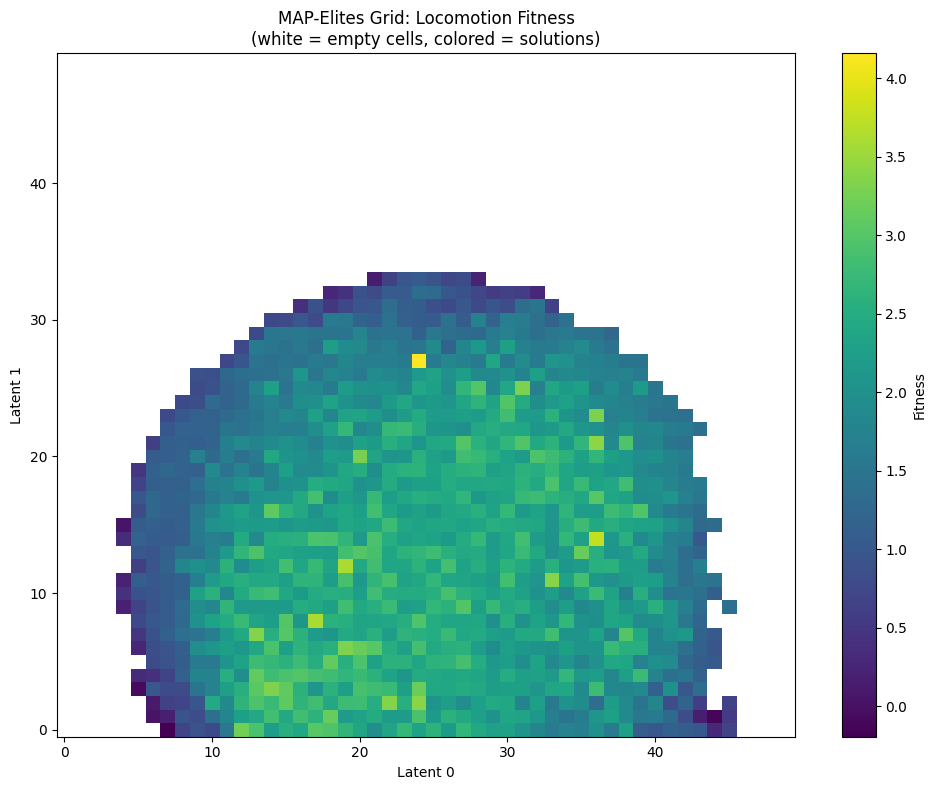


Grid heatmap plotted (white areas = no solutions).


In [6]:
# ==========================================================
# VISUALIZE MAP-ELITES GRID FROM SAVED ARCHIVE
# ==========================================================

import matplotlib.pyplot as plt
import os

# Prefer final archive, fallback to latest checkpoint
final_archive_path = os.path.join(RESULTS_DIR, "map_elites_final.pkl")
checkpoint_files = [
    f for f in os.listdir(CHECKPOINT_DIR)
    if f.startswith('map_elites_iter_') and f.endswith('.pkl')
]

archive_path = None
if os.path.exists(final_archive_path):
    archive_path = final_archive_path
elif checkpoint_files:
    checkpoint_files.sort(key=lambda x: int(x.split('_')[3].split('.')[0]))
    archive_path = os.path.join(CHECKPOINT_DIR, checkpoint_files[-1])

if archive_path is not None:
    print(f"Loading archive: {archive_path}")
    with open(archive_path, 'rb') as f:
        loaded_data = pickle.load(f)

    archive = loaded_data

    print("=" * 60)
    print("MAP-ELITES GRID VISUALIZATION")
    print("=" * 60)

    # Get statistics
    if isinstance(archive, dict) and 'grid' in archive:
        grid = archive.get('grid', {})
        bd_labels = archive.get('bd_labels', ['Dimension 1', 'Dimension 2'])
        fitness_label = archive.get('fitness_label', 'Fitness')
        grid_shape = archive.get('grid_shape', None)

        all_fitnesses = [cell['fitness'] for cell in grid.values()]
        median_fitness = np.median(all_fitnesses) if all_fitnesses else 0.0
        qd_score = sum(all_fitnesses)
        num_filled = len(grid)
        coverage = num_filled / np.prod(grid_shape) if grid_shape else 0.0
        max_fitness = max(all_fitnesses) if all_fitnesses else 0.0
        mean_fitness = np.mean(all_fitnesses) if all_fitnesses else 0.0
    else:
        stats = archive.get_statistics()
        all_fitnesses = [cell['fitness'] for cell in archive.grid.values()]
        median_fitness = np.median(all_fitnesses) if all_fitnesses else 0.0
        qd_score = sum(all_fitnesses)
        num_filled = stats['num_filled']
        coverage = stats['coverage']
        max_fitness = stats['max_fitness']
        mean_fitness = stats['mean_fitness']
        bd_labels = archive.bd_labels
        fitness_label = archive.fitness_label
        grid_shape = archive.grid_shape
        grid = archive.grid

    print(f"Coverage:      {coverage*100:.2f}%")
    print(f"Filled cells:  {num_filled}")
    print(f"Total cells:   {np.prod(grid_shape)}")
    print(f"QD-score:      {qd_score:.4f}")
    print(f"Max fitness:   {max_fitness:.4f}")
    print(f"Mean fitness:  {mean_fitness:.4f}")
    print(f"Median fitness: {median_fitness:.4f}")

    # Create heatmap for 2D behavior descriptors
    if len(grid_shape) == 2:
        heatmap = np.full(grid_shape, np.nan)  # Initialize with NaN (empty cells)
        for grid_idx, cell in grid.items():
            heatmap[grid_idx] = cell['fitness']

        plt.figure(figsize=(10, 8))
        im = plt.imshow(heatmap, cmap='viridis', aspect='auto', origin='lower')
        plt.colorbar(im, label='Fitness')
        plt.xlabel(bd_labels[0])
        plt.ylabel(bd_labels[1])
        plt.title(f"MAP-Elites Grid: {fitness_label}\n(white = empty cells, colored = solutions)")
        plt.tight_layout()
        plt.show()

        print("\nGrid heatmap plotted (white areas = no solutions).")
    else:
        print(f"\n(Grid is {len(grid_shape)}D; heatmap skipped)")
else:
    print(f"No final archive or checkpoints found in {RESULTS_DIR}")


In [7]:
# ==========================================================
# EXPORT TOP SOLUTIONS TO STANDALONE VISUALIZATION SCRIPT
# ==========================================================

import json

if 'archive' in globals():
    num_to_visualize = 5  # Export top 5 solutions

    # Extract grid from archive
    if isinstance(archive, dict) and 'grid' in archive:
        grid = archive.get('grid', {})
    else:
        grid = archive.grid

    # Sort cells by fitness (descending)
    sorted_cells = sorted(
        grid.items(),
        key=lambda x: x[1]['fitness'],
        reverse=True
    )

    top_cells = sorted_cells[:num_to_visualize]

    # Prepare data for export
    solutions_data = {
        'solutions': [],
        'config': {
            'urdf_path': URDF_PATH,
            'duration': SIMULATION_CONFIG['duration'],
            'time_step': SIMULATION_CONFIG['time_step'],
            'sample_interval': SIMULATION_CONFIG['sample_interval'],
        }
    }

    print(f"Exporting top {len(top_cells)} solutions...")
    print("=" * 60)

    for rank, (grid_idx, cell) in enumerate(top_cells, 1):
        genome = cell['genome']
        fitness = cell['fitness']
        bd = cell['bd']

        print(f"[{rank}] Fitness: {fitness:.4f}, BD: {bd}, Grid: {grid_idx}")

        solutions_data['solutions'].append({
            'rank': rank,
            'grid_idx': grid_idx,
            'fitness': float(fitness),
            'bd': bd.tolist() if hasattr(bd, 'tolist') else bd,
            'genome': genome.tolist() if hasattr(genome, 'tolist') else genome,
        })

    # Save to JSON file
    export_path = os.path.join(RESULTS_DIR, 'top_solutions.json')
    with open(export_path, 'w') as f:
        json.dump(solutions_data, f, indent=2)

    print("\n" + "=" * 60)
    print(f"Solutions exported to: {export_path}")
    print("\nTo visualize, run:")
    print("  ./bulletenv/bin/python visualize_top_solutions.py")
else:
    print("No archive loaded. Run the previous visualization/load cell first.")


Exporting top 5 solutions...
[1] Fitness: 4.1606, BD: [0.5523814  0.49895516], Grid: (27, 24)
[2] Fitness: 3.7527, BD: [0.29596692 0.7363811 ], Grid: (14, 36)
[3] Fitness: 3.6051, BD: [0.1756579  0.34710175], Grid: (8, 17)
[4] Fitness: 3.6042, BD: [0.25392818 0.39137444], Grid: (12, 19)
[5] Fitness: 3.4056, BD: [0.43751916 0.7346354 ], Grid: (21, 36)

Solutions exported to: /home/joze/Mestrado/Dissertacao/Pybullet/results/top_solutions.json

To visualize, run:
  ./bulletenv/bin/python visualize_top_solutions.py


In [ ]:
from controllers.hexapod_controller_final import RecurrentTorqueHexapodController
from simulation.simulation_final import HexapodTorqueSimulation

# Open a separate GUI simulation so the random robot is visible even if the
# main experiment notebook was created in headless mode.
gui_sim = HexapodTorqueSimulation(
    urdf_path=URDF_PATH,
    gui=True,
    time_step=SIMULATION_CONFIG['time_step'],
)

random_genome = RecurrentTorqueHexapodController.random_genome()
print(f"Random genome size: {random_genome.size}")
print("Rendering a random robot in the PyBullet GUI...")

try:
    result = gui_sim.evaluate_controller(
        random_genome,
        duration=5.0,
        warmup_time=SIMULATION_CONFIG.get('warmup_time', 2.0),
        render=True,
        controller_interval=SIMULATION_CONFIG.get('controller_interval', 4),
        log_all_steps=False,
    )

    print(f"Fitness: {result['fitness']:.4f}")
    print(f"Behavior descriptors: {result['behavior_descriptors']}")
finally:
    gui_sim.disconnect()

Random genome size: 3282
Rendering a random robot in the PyBullet GUI...
startThreads creating 1 threads.
starting thread 0
started thread 0 
argc=2
argv[0] = --unused
argv[1] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Creating context
Created GL 3.3 context
Direct GLX rendering context obtained
Making context current
GL_VENDOR=Microsoft Corporation
GL_RENDERER=D3D12 (Intel(R) Iris(R) Xe Graphics)
GL_VERSION=4.1 (Core Profile) Mesa 23.2.1-1ubuntu3.1~22.04.3
GL_SHADING_LANGUAGE_VERSION=4.10
pthread_getconcurrency()=0
Version = 4.1 (Core Profile) Mesa 23.2.1-1ubuntu3.1~22.04.3
Vendor = Microsoft Corporation
Renderer = D3D12 (Intel(R) Iris(R) Xe Graphics)
b3Printf: Selected demo: Physics Server
startThreads creating 1 threads.
starting thread 0
started thread 0 
MotionThreadFunc thread started
ven = Microsoft Corporation
ven = Microsoft Corporation
